# Artificial Intelligence Homework 2: CNN Competition

## Problem Statement

### Context

This assignment is a mini AI competition. Each group (Same group from Project) will design
and train a custom Convolutional Neural Network (CNN) to classify images from the subset
of Tiny ImageNet dataset. Your model will be trained and validated using the data provided.
The instructor will test your model on a hidden (unseen) 20% test set that you will not have
access to. Your final score and ranking will depend on your model's accuracy on this unseen
test set.


### Objective

The aim of this project is to design and train a Sequential CNN (from scratch) that performs accurate classification on
Tiny ImageNet data.

### Data Dictionary

???

## Importing necessary libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import math
import cv2

# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Activation,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam,SGD
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

## Loading the dataset

In [ ]:
# Uncomment and run the below code if you are using google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading the dataset
import pickle
train = pickle.load(open("/content/drive/MyDrive/train-70_.pkl", "rb"))
val = pickle.load(open("/content/drive/MyDrive/validation-10_.pkl", "rb"))

## Data Overview

### Understand the shape of the dataset

In [ ]:
# Showing the shape of each key in the dictionary; redundant once we write the dictionary
for key in train:
  print(key, ": ", len(train[key]), sep="")

images: 5775
labels: 5775
class_names: 15
all_classes: 200


In [ ]:
# Separating the images and seeing there are 5775 images of size 64 by 64 with 3 color channels
labels = train['labels']

images = train['images']
images.shape

(5775, 64, 64, 3)

In [ ]:
def plot_images(labels,classes):
  class_indices = {key:[] for key in classes}                                     # Unique classes turned into dictionary keys

  for i, label in enumerate(labels):                                              # Setting every image/label index to its class key
    if label in class_indices:
      class_indices[label].append(i)

  rows = 3                                                                        # Defining number of rows=3
  cols = 5                                                                        # Defining number of columns=5
  fig = plt.figure(figsize=(11, 9))                                               # Defining the figure size to 11x9
  for plot_num, key in enumerate(class_indices, start = 1):
    random_index = random.choice(class_indices[key])                              # Generating a random index for an image of the class
    ax = fig.add_subplot(rows, cols, plot_num)                                    # Adding subplots
    ax.imshow(images[random_index, :])                                            # Plotting the image
    ax.set_title("["+str(key)+"]")                                                # Getting and displaying the class number for the image
  plt.show()                                                                      # Showing the completed plot

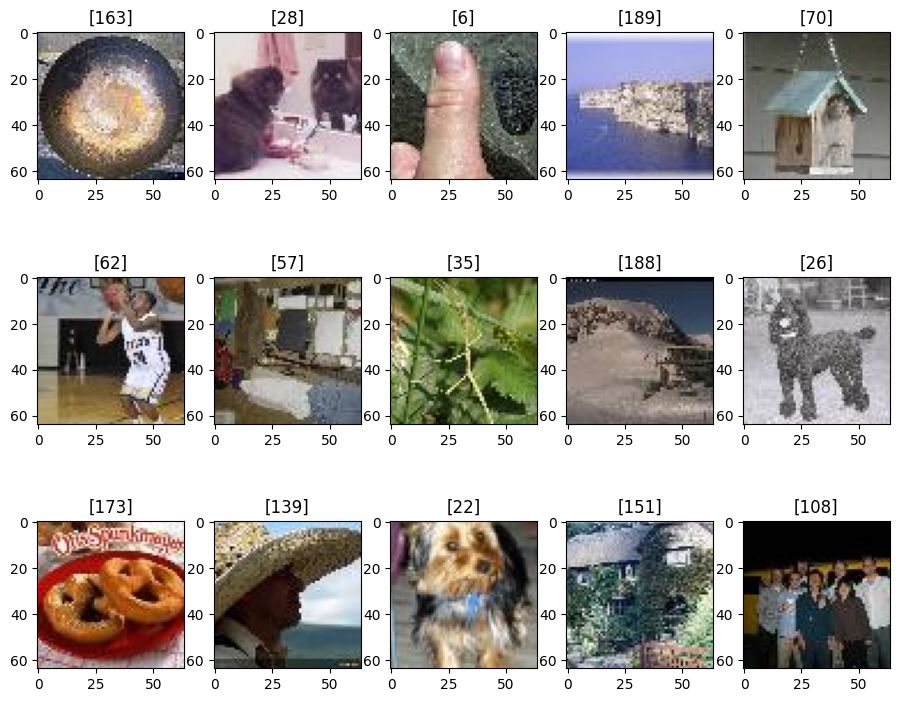

In [ ]:
plot_images(labels,train['class_names'])

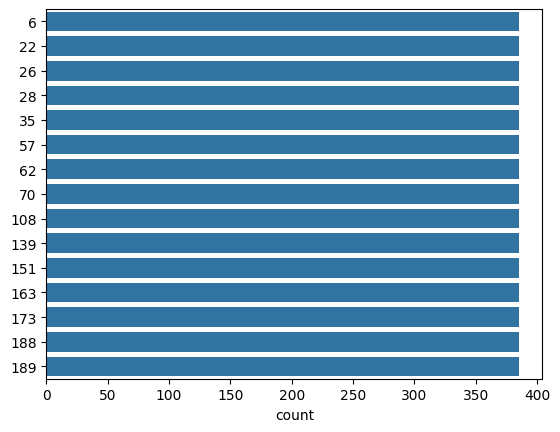

In [68]:
# Creating a small countplot of our classes to see if they're imbalanced
sns.countplot(y=labels)
plt.xticks(rotation='horizontal');